# Notebook 1 — Science as Bayesian Updating
**Modeling Social Behavior** | Smaldino

---

This is the **foundation** of Chapter 8. Before worrying about publication bias, evolutionary pressures, or selection distortions,  
you need to understand the basic logic by which scientific evidence should move beliefs.  
That logic is **Bayesian updating**.

---

## 🧠 Conceptual Overview

### What is science doing, mechanically?

Science is a collective belief-revision machine. Each experiment produces a signal — positive or negative — and that signal should shift our confidence in a hypothesis. The question is: *how much* should it shift, and in *which direction*?

Bayesian reasoning gives us the answer.

---

### Bayes' Theorem (the core engine)

Bayes' theorem tells us how to update a **prior** belief (before seeing data) into a **posterior** belief (after seeing data):

$$P(H | D) = \frac{P(D | H) \cdot P(H)}{P(D)}$$

- $P(H)$ = **prior** — our initial belief that hypothesis H is true  
- $P(D | H)$ = **likelihood** — how probable the data would be *if* H were true  
- $P(H | D)$ = **posterior** — our updated belief after seeing the data  
- $P(D)$ = **marginal likelihood** — the total probability of seeing this data under all hypotheses  

---

### The 2×2 matrix of experimental outcomes

Every experiment produces one of four outcomes. Understanding these is essential:

| | **Hypothesis TRUE** | **Hypothesis FALSE** |
|---|---|---|
| **Positive result** | True Positive (power = β) | False Positive (α) |
| **Negative result** | False Negative (1 − β) | True Negative (1 − α) |

- **Power (β)** — the probability that an experiment *detects* a true effect (sensitivity)
- **False positive rate (α)** — the probability that an experiment *claims* an effect when there is none (Type I error rate)

---

### Bayesian update formulas

**After a POSITIVE result (significant finding published):**

$$P(H | +) = \frac{\beta \cdot P(H)}{\beta \cdot P(H) + \alpha \cdot (1 - P(H))}$$

Intuition: A positive result could come from a true hypothesis (prob = β × prior)  
or from a false hypothesis generating a false positive (prob = α × (1 − prior)).  
We normalize by the total probability of getting a positive result.

**After a NEGATIVE result (null finding):**

$$P(H | -) = \frac{(1 - \beta) \cdot P(H)}{(1 - \beta) \cdot P(H) + (1 - \alpha) \cdot (1 - P(H))}$$

Intuition: A negative result could mean the hypothesis is true but we missed it (false negative)  
or the hypothesis is false and we correctly found nothing (true negative).

---

### What does the simulation teach?

1. **Rational convergence is possible** — with unbiased evidence and enough studies, beliefs converge to the truth regardless of starting prior  
2. **High power matters** — low-powered studies update beliefs very slowly (each result is weak evidence)  
3. **Low α matters** — a high false positive rate injects noise, slowing convergence or even moving beliefs the wrong way  
4. **Prior matters less over time** — with many studies, the prior gets washed out (but it matters early!)  

This is the *ideal* case. Later notebooks introduce distortions.


## Setup — Imports

In [1]:
# ── Standard scientific Python stack ─────────────────────────────────────
import numpy as np                  # numerical operations
import matplotlib.pyplot as plt     # plotting
import matplotlib.ticker as ticker  # axis formatting
from matplotlib.lines import Line2D # custom legend handles

# Set random seed for reproducibility
np.random.seed(42)

# Optional: make plots look clean
plt.rcParams.update({
    "figure.dpi": 120,
    "axes.spines.top": False,
    "axes.spines.right": False,
})


## Parameters

### Variable types
- **Global variables** — single values shared across the whole simulation; set once at the start.  
  Here: `initial_prior`, `false_positive_rate`, `power`, `true_hypothesis`, `max_steps`

There are no agents (no turtles) in this model — it is a **single-trajectory simulation**  
of one idealized scientific community's evolving belief.


In [2]:
# ── GLOBAL VARIABLES ──────────────────────────────────────────────────────
# These mirror the NetLogo sliders exactly.

initial_prior       = 0.1    # P(H) — our starting belief the hypothesis is true
                              # Try: 0.5 (agnostic), 0.9 (very confident), 0.01 (skeptical)

false_positive_rate = 0.05   # α — probability of a positive result when H is FALSE
                              # In classical stats this is your chosen significance threshold

power               = 0.5    # β — probability of detecting an effect when H is TRUE
                              # Many fields operate with power ≈ 0.5; ideal ≥ 0.8

true_hypothesis     = True   # Is the hypothesis actually true? Toggle to False to watch
                              # beliefs drift away from truth under high false positive rates

max_steps           = 100    # How many experiments to run

print("Parameters loaded.")
print(f"  Prior:              {initial_prior}")
print(f"  False positive rate (α): {false_positive_rate}")
print(f"  Power (β):          {power}")
print(f"  True hypothesis:    {true_hypothesis}")
print(f"  Max experiments:    {max_steps}")


Parameters loaded.
  Prior:              0.1
  False positive rate (α): 0.05
  Power (β):          0.5
  True hypothesis:    True
  Max experiments:    100


## Core Logic — Bayesian Update Function

This single function does all the intellectual work.  
Given the current belief and the outcome of one experiment,  
it returns the updated belief using Bayes' theorem.


In [3]:
def bayesian_update(prob_true, result_positive, power, false_positive_rate):
    """
    Perform one step of Bayesian updating.
    
    Parameters
    ----------
    prob_true          : float  — current probability that H is true (prior for this step)
    result_positive    : bool   — True if the experiment returned a positive/significant result
    power              : float  — β, sensitivity of the test
    false_positive_rate: float  — α, false alarm rate of the test
    
    Returns
    -------
    float — updated probability that H is true (posterior)
    
    Variable type: LOCAL (all variables exist only inside this function call)
    """
    
    if result_positive:
        # ── POSITIVE RESULT ───────────────────────────────────────────────
        # Numerator:   probability of (H is true AND we got a positive result)
        #              = P(H) × P(+ | H true) = prob_true × power
        numerator   = power * prob_true
        
        # Denominator: total probability of getting a positive result
        #              = P(+ | H true)×P(H) + P(+ | H false)×P(¬H)
        denominator = (power * prob_true) + (false_positive_rate * (1 - prob_true))
    
    else:
        # ── NEGATIVE RESULT ───────────────────────────────────────────────
        # Numerator:   P(H true AND negative result) = P(H) × P(- | H true)
        #              P(- | H true) = 1 - power  (false negative probability)
        numerator   = (1 - power) * prob_true
        
        # Denominator: total probability of getting a negative result
        #              = P(- | H true)×P(H) + P(- | H false)×P(¬H)
        #              P(- | H false) = 1 - α  (true negative probability)
        denominator = ((1 - power) * prob_true) + ((1 - false_positive_rate) * (1 - prob_true))
    
    # Guard: avoid division by zero (extremely unlikely but defensive)
    if denominator == 0:
        return prob_true
    
    return numerator / denominator   # posterior = updated belief

# Quick sanity check
p = bayesian_update(0.5, result_positive=True, power=0.8, false_positive_rate=0.05)
print(f"Starting at 0.5, after one strong positive result → {p:.4f}")


Starting at 0.5, after one strong positive result → 0.9412


## Simulation — Run the Belief Trajectory

We run `max_steps` experiments. Each step:
1. Draw a random number to decide the experimental outcome (given truth + power + α)
2. Apply the Bayesian update
3. Record the new belief

This mimics one scientific community testing one hypothesis over time.


In [4]:
def run_simulation(initial_prior, power, false_positive_rate, true_hypothesis, max_steps):
    """
    Run the full Bayesian updating simulation.
    
    Parameters  (all GLOBAL values passed in explicitly for clarity)
    ----------
    initial_prior       : float — starting belief P(H)
    power               : float — β
    false_positive_rate : float — α
    true_hypothesis     : bool  — ground truth
    max_steps           : int   — number of experiments
    
    Returns
    -------
    history   : list of floats — P(H) at each time step
    outcomes  : list of bools  — True = positive result at that step
    """
    
    # LOCAL variable: current belief, starts at the prior
    prob_true = initial_prior
    
    history  = [prob_true]   # record the starting belief
    outcomes = []            # record each experimental outcome
    
    for step in range(max_steps):
        
        # ── Determine the experimental outcome ────────────────────────────
        # The outcome depends on whether the hypothesis is actually true.
        
        if true_hypothesis:
            # H is TRUE → detect it with probability = power (β)
            result_positive = (np.random.random() < power)
        else:
            # H is FALSE → false alarm with probability = false_positive_rate (α)
            result_positive = (np.random.random() < false_positive_rate)
        
        outcomes.append(result_positive)
        
        # ── Update belief using Bayes' theorem ────────────────────────────
        prob_true = bayesian_update(prob_true, result_positive, power, false_positive_rate)
        history.append(prob_true)
    
    return history, outcomes

# ── Run with current parameters ───────────────────────────────────────────
history, outcomes = run_simulation(
    initial_prior, power, false_positive_rate, true_hypothesis, max_steps
)

final_belief = history[-1]
pos_count    = sum(outcomes)
neg_count    = len(outcomes) - pos_count

print(f"Simulation complete: {max_steps} experiments run")
print(f"  Positive results : {pos_count}")
print(f"  Negative results : {neg_count}")
print(f"  Starting belief  : {initial_prior:.3f}")
print(f"  Final belief     : {final_belief:.3f}")


Simulation complete: 100 experiments run
  Positive results : 53
  Negative results : 47
  Starting belief  : 0.100
  Final belief     : 1.000


## Visualization 1 — Single Run Trajectory

The x-axis is the experiment number; the y-axis is the current probability assigned to the hypothesis.  
Watch how it wiggles up on positive results and down on negative ones.


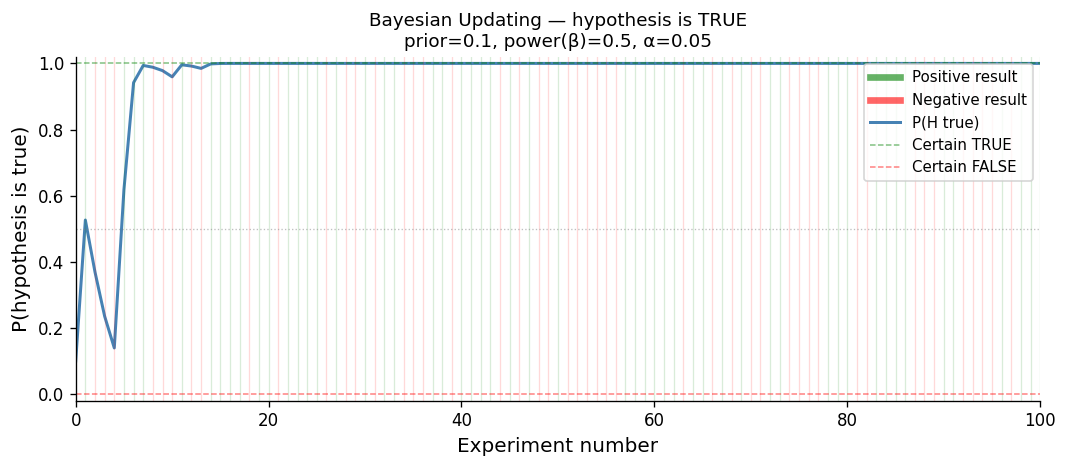

In [5]:
fig, ax = plt.subplots(figsize=(9, 4))

# ── Plot the belief trajectory ─────────────────────────────────────────────
ax.plot(history, color="steelblue", linewidth=1.8, label="P(H true)")

# ── Mark positive / negative outcomes as tick marks along the bottom ───────
for i, pos in enumerate(outcomes):
    color = "green" if pos else "red"
    ax.axvline(x=i+1, color=color, alpha=0.15, linewidth=0.8)

# ── Reference lines ────────────────────────────────────────────────────────
ax.axhline(1.0, color="green", linestyle="--", linewidth=0.9, alpha=0.5, label="Certain TRUE")
ax.axhline(0.0, color="red",   linestyle="--", linewidth=0.9, alpha=0.5, label="Certain FALSE")
ax.axhline(0.5, color="gray",  linestyle=":",  linewidth=0.8, alpha=0.5, label="50/50")

# ── Labels ─────────────────────────────────────────────────────────────────
ax.set_xlabel("Experiment number", fontsize=12)
ax.set_ylabel("P(hypothesis is true)", fontsize=12)
truth_str = "TRUE" if true_hypothesis else "FALSE"
ax.set_title(
    f"Bayesian Updating — hypothesis is {truth_str}\n"
    f"prior={initial_prior}, power(β)={power}, α={false_positive_rate}",
    fontsize=11
)
ax.set_ylim(-0.02, 1.02)
ax.set_xlim(0, max_steps)
ax.legend(loc="upper right", fontsize=9)

# Custom legend entries for the background shading
legend_elements = [
    Line2D([0],[0], color="green", alpha=0.6, lw=4, label="Positive result"),
    Line2D([0],[0], color="red",   alpha=0.6, lw=4, label="Negative result"),
]
ax.legend(handles=legend_elements + ax.get_legend_handles_labels()[0][:3],
          loc="upper right", fontsize=9)

plt.tight_layout()
plt.show()


## Visualization 2 — Many Runs (Stochastic Variation)

Each run of the simulation is a different random sequence of experiments.  
Here we run the same parameters many times to show the **distribution of possible trajectories**.  
Science doesn't follow a smooth path — individual communities get lucky or unlucky with their samples.


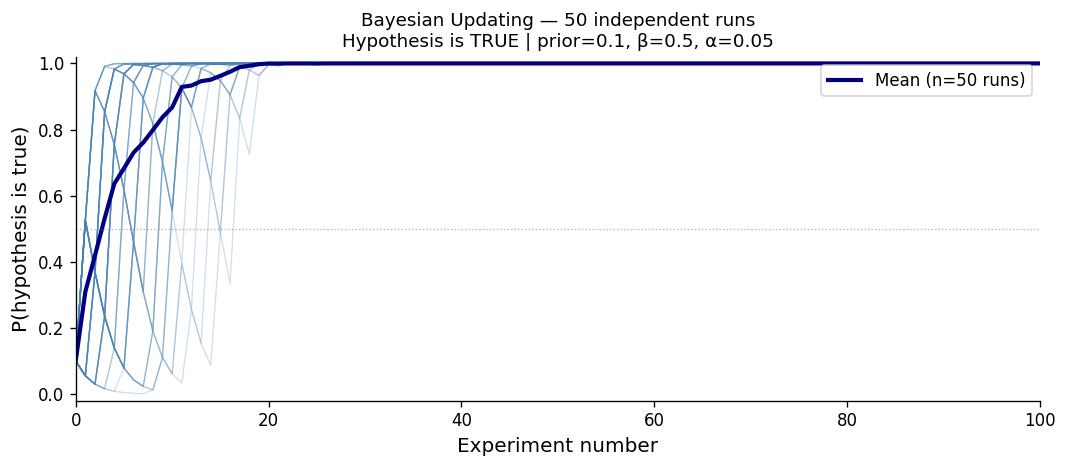

Final belief range across runs: 1.000 – 1.000
Mean final belief: 1.000


In [6]:
n_runs = 50    # number of independent scientific communities to simulate

fig, ax = plt.subplots(figsize=(9, 4))

all_histories = []

for run in range(n_runs):
    h, _ = run_simulation(initial_prior, power, false_positive_rate, true_hypothesis, max_steps)
    all_histories.append(h)
    # Plot each trajectory in a faint color
    ax.plot(h, color="steelblue", alpha=0.25, linewidth=0.8)

# ── Compute and plot the mean trajectory across all runs ──────────────────
mean_history = np.mean(all_histories, axis=0)
ax.plot(mean_history, color="navy", linewidth=2.5, label=f"Mean (n={n_runs} runs)")

# ── Reference lines ────────────────────────────────────────────────────────
ax.axhline(0.5, color="gray", linestyle=":", linewidth=0.8, alpha=0.6)
truth_str = "TRUE" if true_hypothesis else "FALSE"
ax.set_title(
    f"Bayesian Updating — {n_runs} independent runs\n"
    f"Hypothesis is {truth_str} | prior={initial_prior}, β={power}, α={false_positive_rate}",
    fontsize=11
)
ax.set_xlabel("Experiment number", fontsize=12)
ax.set_ylabel("P(hypothesis is true)", fontsize=12)
ax.set_ylim(-0.02, 1.02)
ax.set_xlim(0, max_steps)
ax.legend(fontsize=10)

plt.tight_layout()
plt.show()
print(f"Final belief range across runs: {min(h[-1] for h in all_histories):.3f} – {max(h[-1] for h in all_histories):.3f}")
print(f"Mean final belief: {mean_history[-1]:.3f}")


## Visualization 3 — Parameter Exploration

How do **power** and **false positive rate** affect the speed and accuracy of convergence?  
We vary each systematically and plot the mean trajectory.


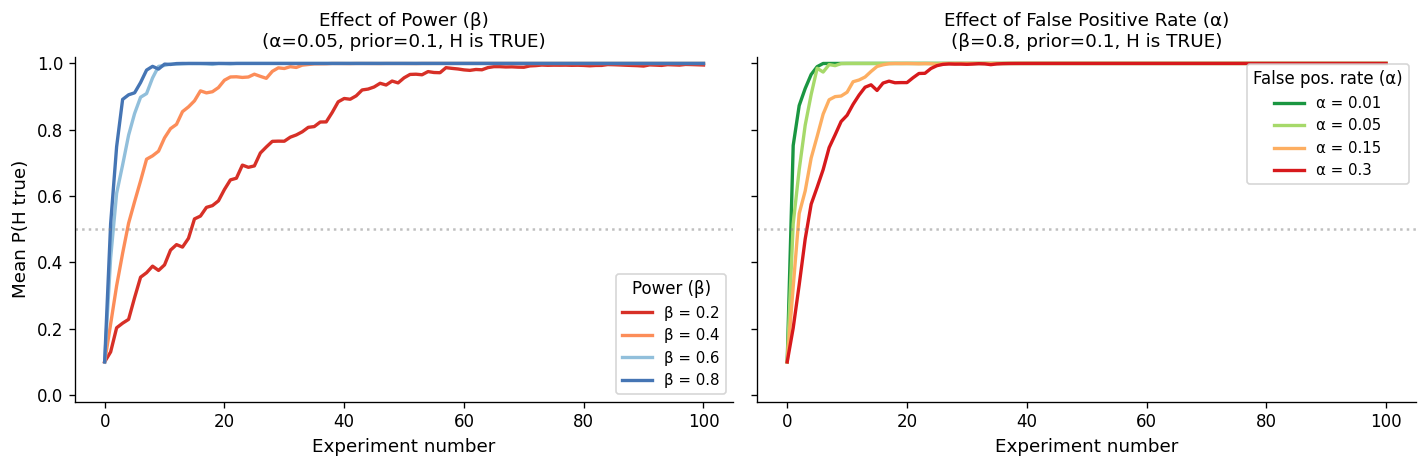

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
n_runs_explore = 30

# ── Left panel: vary power, fix α ─────────────────────────────────────────
ax = axes[0]
power_values = [0.2, 0.4, 0.6, 0.8]
colors_power = ["#d73027", "#fc8d59", "#91bfdb", "#4575b4"]

for pwr, col in zip(power_values, colors_power):
    run_means = []
    for _ in range(n_runs_explore):
        h, _ = run_simulation(
            initial_prior=0.1,
            power=pwr,
            false_positive_rate=0.05,
            true_hypothesis=True,
            max_steps=max_steps
        )
        run_means.append(h)
    mean_h = np.mean(run_means, axis=0)
    ax.plot(mean_h, color=col, linewidth=2, label=f"β = {pwr}")

ax.set_title("Effect of Power (β)\n(α=0.05, prior=0.1, H is TRUE)", fontsize=11)
ax.set_xlabel("Experiment number", fontsize=11)
ax.set_ylabel("Mean P(H true)", fontsize=11)
ax.set_ylim(-0.02, 1.02)
ax.legend(title="Power (β)", fontsize=9)
ax.axhline(0.5, color="gray", linestyle=":", alpha=0.5)

# ── Right panel: vary α, fix power ────────────────────────────────────────
ax = axes[1]
alpha_values = [0.01, 0.05, 0.15, 0.30]
colors_alpha = ["#1a9641", "#a6d96a", "#fdae61", "#d7191c"]

for alpha, col in zip(alpha_values, colors_alpha):
    run_means = []
    for _ in range(n_runs_explore):
        h, _ = run_simulation(
            initial_prior=0.1,
            power=0.8,
            false_positive_rate=alpha,
            true_hypothesis=True,
            max_steps=max_steps
        )
        run_means.append(h)
    mean_h = np.mean(run_means, axis=0)
    ax.plot(mean_h, color=col, linewidth=2, label=f"α = {alpha}")

ax.set_title("Effect of False Positive Rate (α)\n(β=0.8, prior=0.1, H is TRUE)", fontsize=11)
ax.set_xlabel("Experiment number", fontsize=11)
ax.legend(title="False pos. rate (α)", fontsize=9)
ax.axhline(0.5, color="gray", linestyle=":", alpha=0.5)

plt.tight_layout()
plt.show()

## Visualization 4 — When the Hypothesis is FALSE

What happens to beliefs when H is actually false?  
Ideally beliefs should drift toward 0. But high α disrupts this.


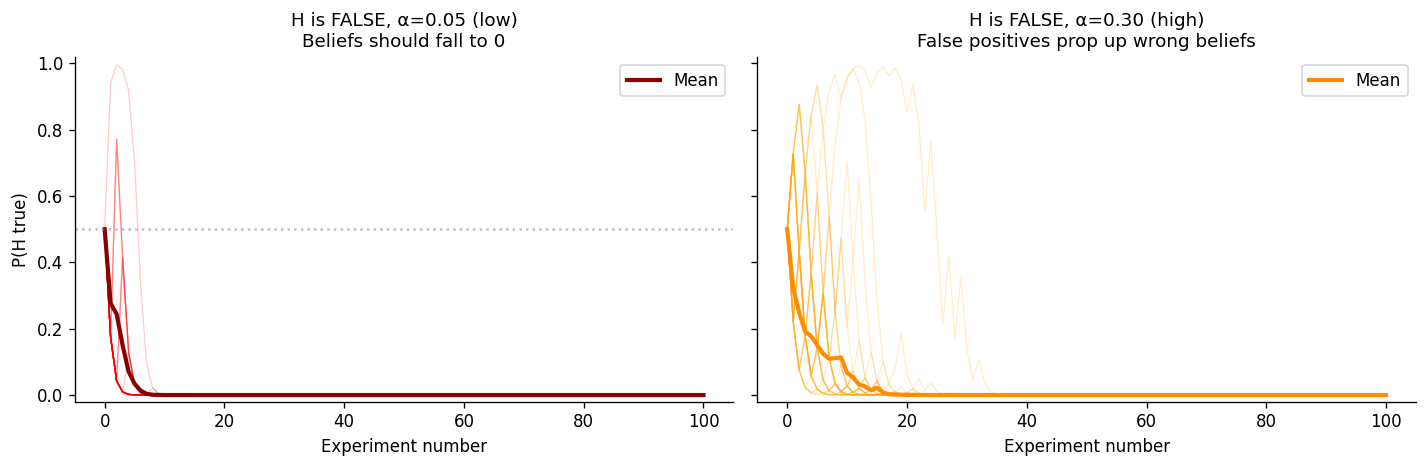

Key insight: With a high false positive rate (α=0.30), the community may never
correctly identify a false hypothesis. Bad measurement corrupts collective knowledge.


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
n_runs_false = 30

# ── Left: low α (good): beliefs correctly converge to 0 ──────────────────
ax = axes[0]
for _ in range(n_runs_false):
    h, _ = run_simulation(0.5, power=0.8, false_positive_rate=0.05,
                          true_hypothesis=False, max_steps=100)
    ax.plot(h, color="red", alpha=0.2, linewidth=0.8)
# Mean
means = np.mean([run_simulation(0.5, 0.8, 0.05, False, 100)[0] for _ in range(n_runs_false)], axis=0)
ax.plot(means, color="darkred", linewidth=2.5, label="Mean")
ax.set_title("H is FALSE, α=0.05 (low)\nBeliefs should fall to 0", fontsize=11)
ax.set_xlabel("Experiment number"); ax.set_ylabel("P(H true)"); ax.set_ylim(-0.02,1.02)
ax.axhline(0.5, color="gray", linestyle=":", alpha=0.5); ax.legend()

# ── Right: high α (bad): false positives prop up wrong beliefs ────────────
ax = axes[1]
for _ in range(n_runs_false):
    h, _ = run_simulation(0.5, power=0.8, false_positive_rate=0.30,
                          true_hypothesis=False, max_steps=100)
    ax.plot(h, color="orange", alpha=0.2, linewidth=0.8)
means = np.mean([run_simulation(0.5, 0.8, 0.30, False, 100)[0] for _ in range(n_runs_false)], axis=0)
ax.plot(means, color="darkorange", linewidth=2.5, label="Mean")
ax.set_title("H is FALSE, α=0.30 (high)\nFalse positives prop up wrong beliefs", fontsize=11)
ax.set_xlabel("Experiment number"); ax.legend()

plt.tight_layout()
plt.show()

print("Key insight: With a high false positive rate (α=0.30), the community may never")
print("correctly identify a false hypothesis. Bad measurement corrupts collective knowledge.")


## 📝 Key Takeaways

| Concept | What the simulation shows |
|---------|--------------------------|
| **Prior doesn't dominate forever** | With enough studies, evidence overwhelms the starting belief |
| **High power (β) → faster convergence** | More sensitive tests produce clearer signals per study |
| **Low α → cleaner learning** | Fewer false alarms means each positive result is more diagnostic |
| **H is false + high α** | Beliefs can stay *incorrectly elevated* for a long time, or forever |
| **Stochasticity matters** | Individual scientific communities get lucky or unlucky — only in aggregate does the ideal emerge |

### What this model assumes (and the next notebooks will break)
- Every result — positive **and** negative — gets published  
- Scientists update their beliefs according to Bayes' theorem  
- There is no competitive pressure or incentive distortion  

These are unrealistic assumptions. Notebook 2 introduces **selection bias**, and Notebooks 3 & 4 break the publishing assumption in different ways.


